## PRACTICA OBLIGATORIA: **Selección de Features**

Dataset: `credit_npo.csv` — Predicción de `SeriousDlqin2yrs` (impago grave en 2 años)

### Ejercicio 0 — Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Selección de features
from sklearn.feature_selection import (
    SelectKBest, f_classif, mutual_info_classif,
    SelectFromModel, RFE
)
from sklearn.feature_selection import SequentialFeatureSelector as SFS

# Modelos
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Métricas
from sklearn.metrics import recall_score, classification_report, confusion_matrix

# PCA
from sklearn.decomposition import PCA

# Dimensión reducida
from sklearn.utils import resample

print('Librerías importadas correctamente')

Librerías importadas correctamente


### Carga y preparación del dataset

In [2]:
df = pd.read_csv('credit_npo.csv')
print('Shape original:', df.shape)
df.head()

Shape original: (12537, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), 

In [4]:
print('Nulos por columna:')
print(df.isnull().sum())

Nulos por columna:
SeriousDlqin2yrs                          0
RevolvingUtilizationOfUnsecuredLines      0
age                                       0
NumberOfTime30-59DaysPastDueNotWorse      0
DebtRatio                                 0
MonthlyIncome                           721
NumberOfOpenCreditLinesAndLoans           0
NumberOfTimes90DaysLate                   0
NumberRealEstateLoansOrLines              0
NumberOfTime60-89DaysPastDueNotWorse      0
NumberOfDependents                      177
dtype: int64


### Ejercicio 1 — Limpieza y transformación de features

In [5]:
# Eliminar filas con nulos
df = df.dropna()
print('Shape tras eliminar nulos:', df.shape)

# Verificar balance de clases
print('\nBalance de la variable objetivo:')
print(df['SeriousDlqin2yrs'].value_counts(normalize=True).round(3))

Shape tras eliminar nulos: (11816, 11)

Balance de la variable objetivo:
SeriousDlqin2yrs
0    0.93
1    0.07
Name: proportion, dtype: float64


In [6]:
# Convertir features NumberOf... a categóricas con bins
# NumberOfTime30-59DaysPastDueNotWorse -> 0, 1, 2+
def bin_past_due(x):
    if x == 0: return 0
    elif x == 1: return 1
    else: return 2

df['cat_30_59'] = df['NumberOfTime30-59DaysPastDueNotWorse'].apply(bin_past_due)
df['cat_60_89'] = df['NumberOfTime60-89DaysPastDueNotWorse'].apply(bin_past_due)
df['cat_90late'] = df['NumberOfTimes90DaysLate'].apply(bin_past_due)

# Convertir dependientes: 0, 1, 2+
df['cat_dependents'] = df['NumberOfDependents'].apply(lambda x: min(int(x), 2))

# Bins para open credit lines: bajo (<=4), medio (5-9), alto (10+)
df['cat_open_credit'] = pd.cut(df['NumberOfOpenCreditLinesAndLoans'],
                                bins=[-1, 4, 9, 100], labels=[0, 1, 2]).astype(int)

# Bins para real estate loans: 0, 1, 2+
df['cat_real_estate'] = df['NumberRealEstateLoansOrLines'].apply(bin_past_due)

print('Features categóricas creadas')
df[['cat_30_59','cat_60_89','cat_90late','cat_dependents','cat_open_credit','cat_real_estate']].head()

Features categóricas creadas


,cat_30_59,cat_60_89,cat_90late,cat_dependents,cat_open_credit,cat_real_estate
0,0,0,1,0,2,0
1,0,0,0,0,1,1
2,0,0,0,2,0,0
3,0,0,0,2,0,2
4,0,0,0,1,0,0


In [7]:
# Definir features numéricas y categóricas
num_features = ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome']
cat_features = ['cat_30_59', 'cat_60_89', 'cat_90late', 'cat_dependents', 'cat_open_credit', 'cat_real_estate']
all_features = num_features + cat_features
target = 'SeriousDlqin2yrs'

X = df[all_features].copy()
y = df[target].copy()

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (9452, 10) | Test: (2364, 10)


### Ejercicio 2 — Mini EDA y Selección de Features

#### 2.1 Análisis visual + correlación + covarianza

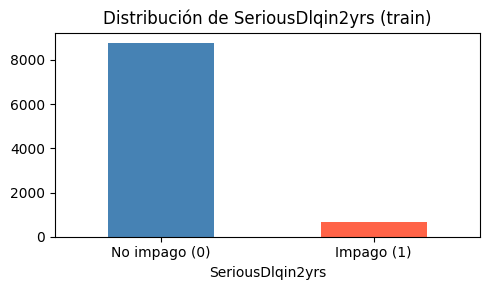

In [8]:
# Distribución de la variable objetivo
fig, ax = plt.subplots(figsize=(5, 3))
y_train.value_counts().plot(kind='bar', ax=ax, color=['steelblue','tomato'])
ax.set_title('Distribución de SeriousDlqin2yrs (train)')
ax.set_xticklabels(['No impago (0)', 'Impago (1)'], rotation=0)
plt.tight_layout()
plt.show()

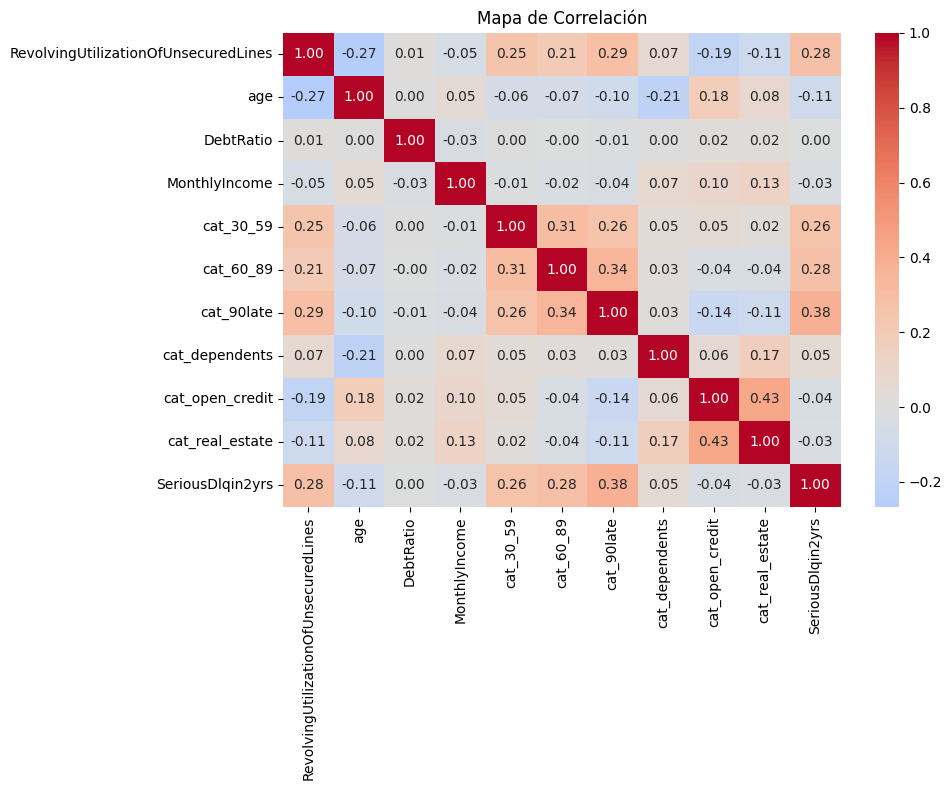

In [9]:
# Mapa de correlación
train_df = X_train.copy()
train_df[target] = y_train.values

corr_matrix = train_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Mapa de Correlación')
plt.tight_layout()
plt.show()

In [10]:
# Correlación de features con el target
corr_target = corr_matrix[target].drop(target).abs().sort_values(ascending=False)
print('Correlación con la variable objetivo (|r|):')
print(corr_target.round(4))

# Umbral de correlación: conservamos features con |r| > 0.05
CORR_THRESHOLD = 0.05
features_by_corr = corr_target[corr_target > CORR_THRESHOLD].index.tolist()
print(f'\nFeatures con |r| > {CORR_THRESHOLD}: {features_by_corr}')

Correlación con la variable objetivo (|r|):
cat_90late                              0.3780
RevolvingUtilizationOfUnsecuredLines    0.2775
cat_60_89                               0.2762
cat_30_59                               0.2590
age                                     0.1053
cat_dependents                          0.0505
cat_open_credit                         0.0442
cat_real_estate                         0.0268
MonthlyIncome                           0.0254
DebtRatio                               0.0001
Name: SeriousDlqin2yrs, dtype: float64

Features con |r| > 0.05: ['cat_90late', 'RevolvingUtilizationOfUnsecuredLines', 'cat_60_89', 'cat_30_59', 'age', 'cat_dependents']


In [11]:
# Eliminar features con alta correlación entre sí (umbral de covarianza 0.85)
# Calculamos la matriz de correlación entre features (sin target)
corr_feat = X_train[features_by_corr].corr().abs()
upper_tri = corr_feat.where(np.triu(np.ones(corr_feat.shape), k=1).astype(bool))
to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > 0.85)]
print('Features con correlación mutua > 0.85 (eliminar):', to_drop)

# Lista final por método 1
lista_1 = [f for f in features_by_corr if f not in to_drop][:6]
print('\nLista 1 (correlación + covarianza):', lista_1)

Features con correlación mutua > 0.85 (eliminar): []

Lista 1 (correlación + covarianza): ['cat_90late', 'RevolvingUtilizationOfUnsecuredLines', 'cat_60_89', 'cat_30_59', 'age', 'cat_dependents']


#### 2.2 SelectKBest (ANOVA) para numéricas + Mutual Information para categóricas

In [12]:
# SelectKBest con ANOVA F-score para features numéricas
skb_num = SelectKBest(score_func=f_classif, k='all')
skb_num.fit(X_train[num_features], y_train)

scores_num = pd.Series(skb_num.scores_, index=num_features).sort_values(ascending=False)
print('ANOVA F-scores (features numéricas):')
print(scores_num.round(2))

# Seleccionamos top 3 numéricas
top_num = scores_num.head(3).index.tolist()
print('\nTop 3 numéricas:', top_num)

ANOVA F-scores (features numéricas):
RevolvingUtilizationOfUnsecuredLines    788.27
age                                     105.86
MonthlyIncome                             6.12
DebtRatio                                 0.00
dtype: float64

Top 3 numéricas: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome']


In [13]:
# Mutual Information para features categóricas
mi_scores = mutual_info_classif(X_train[cat_features], y_train, random_state=42)
scores_cat = pd.Series(mi_scores, index=cat_features).sort_values(ascending=False)
print('Mutual Information scores (features categóricas):')
print(scores_cat.round(4))

# Seleccionamos top 3 categóricas
top_cat = scores_cat.head(3).index.tolist()
print('\nTop 3 categóricas:', top_cat)

Mutual Information scores (features categóricas):
cat_90late         0.0341
cat_30_59          0.0251
cat_60_89          0.0206
cat_open_credit    0.0074
cat_dependents     0.0032
cat_real_estate    0.0029
dtype: float64

Top 3 categóricas: ['cat_90late', 'cat_30_59', 'cat_60_89']


In [14]:
# Combinamos en lista 2
lista_2 = (top_num + top_cat)[:6]
print('Lista 2 (SelectKBest ANOVA + MI):', lista_2)

Lista 2 (SelectKBest ANOVA + MI): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome', 'cat_90late', 'cat_30_59', 'cat_60_89']


#### 2.3 SelectFromModel (modelo intermedio)

Lista 3 (SelectFromModel - RandomForest): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'cat_30_59', 'cat_90late']


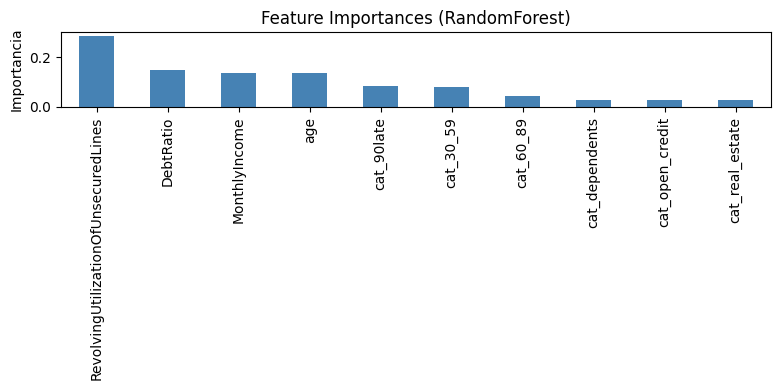

In [15]:
# Usamos un RandomForest como modelo intermedio
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
sfm = SelectFromModel(rf_base, max_features=6, threshold=-np.inf)
sfm.fit(X_train, y_train)

lista_3 = list(X_train.columns[sfm.get_support()])
print('Lista 3 (SelectFromModel - RandomForest):', lista_3)

# Importancias del modelo base
importancias = pd.Series(sfm.estimator_.feature_importances_, index=all_features).sort_values(ascending=False)
importancias.plot(kind='bar', figsize=(8,4), color='steelblue')
plt.title('Feature Importances (RandomForest)')
plt.ylabel('Importancia')
plt.tight_layout()
plt.show()

#### 2.4 RFE (Recursive Feature Elimination)

In [16]:
# RFE con Logistic Regression
lr_rfe = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
rfe = RFE(estimator=lr_rfe, n_features_to_select=6)

# Escalamos para LR
scaler_rfe = StandardScaler()
X_train_scaled = scaler_rfe.fit_transform(X_train)

rfe.fit(X_train_scaled, y_train)

lista_4 = list(X_train.columns[rfe.support_])
print('Lista 4 (RFE - Logistic Regression):', lista_4)

ranking = pd.Series(rfe.ranking_, index=all_features).sort_values()
print('\nRanking RFE:')
print(ranking)

Lista 4 (RFE - Logistic Regression): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'cat_30_59', 'cat_60_89', 'cat_90late', 'cat_real_estate']

Ranking RFE:
RevolvingUtilizationOfUnsecuredLines    1
age                                     1
cat_30_59                               1
cat_60_89                               1
cat_90late                              1
cat_real_estate                         1
MonthlyIncome                           2
cat_open_credit                         3
cat_dependents                          4
DebtRatio                               5
dtype: int64


#### 2.5 SFS (Sequential Feature Selection)

In [17]:
# SFS forward con Decision Tree (sklearn built-in, más rápido)
dt_sfs = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')

sfs = SFS(
    dt_sfs,
    n_features_to_select=6,
    direction='forward',
    scoring='recall',
    cv=3,
    n_jobs=-1
)

sfs.fit(X_train, y_train)

lista_5 = list(X_train.columns[sfs.get_support()])
print('Lista 5 (SFS - Decision Tree):', lista_5)

Lista 5 (SFS - Decision Tree): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome', 'cat_dependents', 'cat_open_credit', 'cat_real_estate']


#### 2.6 Hard-Voting sobre las listas 1-5

Votos por feature:
RevolvingUtilizationOfUnsecuredLines    5
age                                     5
cat_90late                              4
cat_30_59                               4
cat_60_89                               3
MonthlyIncome                           3
cat_dependents                          2
cat_real_estate                         2
DebtRatio                               1
cat_open_credit                         1
dtype: int64

Lista 6 (Hard Voting): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'cat_90late', 'cat_30_59', 'cat_60_89', 'MonthlyIncome']


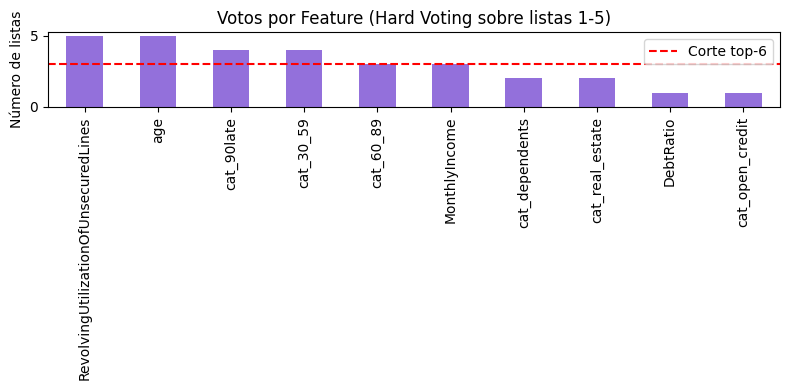

In [18]:
from collections import Counter

todas_las_listas = [lista_1, lista_2, lista_3, lista_4, lista_5]

# Contar cuántas listas incluyen cada feature
votos = Counter(f for lst in todas_las_listas for f in lst)
votos_df = pd.Series(votos).sort_values(ascending=False)

print('Votos por feature:')
print(votos_df)

# Seleccionamos las 6 con más votos
lista_6 = votos_df.head(6).index.tolist()
print('\nLista 6 (Hard Voting):', lista_6)

# Visualización
votos_df.plot(kind='bar', figsize=(8, 4), color='mediumpurple')
plt.title('Votos por Feature (Hard Voting sobre listas 1-5)')
plt.ylabel('Número de listas')
plt.axhline(y=votos_df.iloc[5] if len(votos_df) > 5 else 1, color='red', linestyle='--', label='Corte top-6')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# Resumen de las 6 listas
print('=== RESUMEN DE LAS 6 LISTAS DE FEATURES ===')
for i, lst in enumerate([lista_1, lista_2, lista_3, lista_4, lista_5, lista_6], 1):
    print(f'Lista {i}: {lst}')

=== RESUMEN DE LAS 6 LISTAS DE FEATURES ===
Lista 1: ['cat_90late', 'RevolvingUtilizationOfUnsecuredLines', 'cat_60_89', 'cat_30_59', 'age', 'cat_dependents']
Lista 2: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome', 'cat_90late', 'cat_30_59', 'cat_60_89']
Lista 3: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'cat_30_59', 'cat_90late']
Lista 4: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'cat_30_59', 'cat_60_89', 'cat_90late', 'cat_real_estate']
Lista 5: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome', 'cat_dependents', 'cat_open_credit', 'cat_real_estate']
Lista 6: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'cat_90late', 'cat_30_59', 'cat_60_89', 'MonthlyIncome']


### Ejercicio 3 — Comparativa de 3 modelos × 6 listas (18 experimentos)

Métrica: **recall medio** (especialmente relevante para detectar impagos — minimizar falsos negativos)

In [20]:
# Los 3 modelos candidatos
modelos = {
    'RandomForest':       RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'GradientBoosting':   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

listas_features = {
    'Lista1_Correlacion':  lista_1,
    'Lista2_KBest_MI':     lista_2,
    'Lista3_SFM':          lista_3,
    'Lista4_RFE':          lista_4,
    'Lista5_SFS':          lista_5,
    'Lista6_HardVoting':   lista_6,
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()

resultados = []

for nombre_modelo, modelo in modelos.items():
    for nombre_lista, features in listas_features.items():
        # Pipeline con escalado
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', modelo)
        ])
        scores = cross_val_score(
            pipe, X_train[features], y_train,
            cv=cv, scoring='recall', n_jobs=-1
        )
        resultados.append({
            'Modelo': nombre_modelo,
            'Lista': nombre_lista,
            'Recall_medio': scores.mean().round(4),
            'Recall_std': scores.std().round(4)
        })
        print(f'{nombre_modelo} | {nombre_lista} -> Recall: {scores.mean():.4f} ± {scores.std():.4f}')

resultados_df = pd.DataFrame(resultados)
print('\n=== RESULTADOS COMPLETOS ===')
print(resultados_df.sort_values('Recall_medio', ascending=False).to_string(index=False))

RandomForest | Lista1_Correlacion -> Recall: 0.2049 ± 0.0320


RandomForest | Lista2_KBest_MI -> Recall: 0.1913 ± 0.0270


RandomForest | Lista3_SFM -> Recall: 0.1838 ± 0.0298


RandomForest | Lista4_RFE -> Recall: 0.2245 ± 0.0246


RandomForest | Lista5_SFS -> Recall: 0.0436 ± 0.0129


...

GradientBoosting | Lista2_KBest_MI -> Recall: 0.2215 ± 0.0379


GradientBoosting | Lista3_SFM -> Recall: 0.2139 ± 0.0252


GradientBoosting | Lista4_RFE -> Recall: 0.2154 ± 0.0206


GradientBoosting | Lista5_SFS -> Recall: 0.0497 ± 0.0188


GradientBoosting | Lista6_HardVoting -> Recall: 0.2200 ± 0.0390

=== RESULTADOS COMPLETOS ===
            Modelo              Lista  Recall_medio  Recall_std
LogisticRegression         Lista4_RFE        0.7275      0.0300
LogisticRegression         Lista5_SFS        0.7274      0.0301
LogisticRegression         Lista3_SFM        0.7199      0.0230
LogisticRegression Lista1_Correlacion        0.7169      0.0188
LogisticRegression  Lista6_HardVoting        0.7124      0.0217
LogisticRegression    Lista2_KBest_MI        0.7124      0.0217
      RandomForest         Lista4_RFE        0.2245      0.0246
  GradientBoosting    Lista2_KBest_MI        0.2215      0.0379
  GradientBoosting  Lista6_HardVoting        0.2200      0.0390
  GradientBoosting         Lista4_RFE        0.2154      0.0206
  GradientBoosting         Lista3_SFM        0.2139      0.0252
  GradientBoosting Lista1_Correlacion        0.2049      0.0282
      RandomForest Lista1_Correlacion        0.2049      0.0320
      Rand

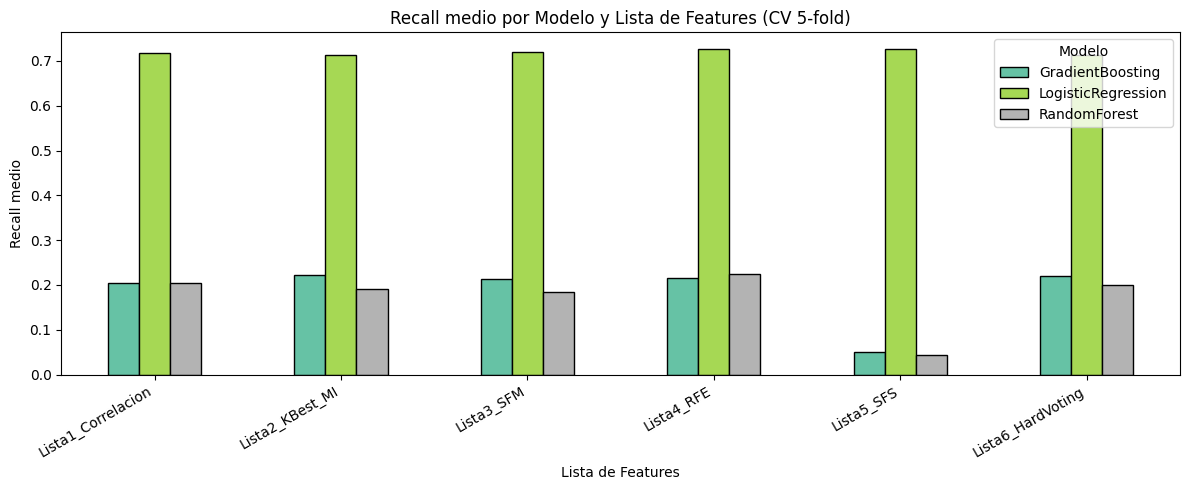

In [21]:
# Visualización comparativa
pivot = resultados_df.pivot(index='Lista', columns='Modelo', values='Recall_medio')
pivot.plot(kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='black')
plt.title('Recall medio por Modelo y Lista de Features (CV 5-fold)')
plt.ylabel('Recall medio')
plt.xlabel('Lista de Features')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Modelo')
plt.tight_layout()
plt.show()

In [22]:
# Ganador
mejor = resultados_df.loc[resultados_df['Recall_medio'].idxmax()]
print('=== MEJOR COMBINACIÓN ===')
print(mejor)
modelo_ganador_nombre = mejor['Modelo']
lista_ganadora_nombre = mejor['Lista']
features_ganadoras = listas_features[lista_ganadora_nombre]
print(f'\nModelo ganador: {modelo_ganador_nombre}')
print(f'Lista ganadora: {lista_ganadora_nombre}')
print(f'Features: {features_ganadoras}')

=== MEJOR COMBINACIÓN ===
Modelo          LogisticRegression
Lista                   Lista4_RFE
Recall_medio                0.7275
Recall_std                    0.03
Name: 9, dtype: object

Modelo ganador: LogisticRegression
Lista ganadora: Lista4_RFE
Features: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'cat_30_59', 'cat_60_89', 'cat_90late', 'cat_real_estate']


### Ejercicio 4 — Optimización de hiperparámetros y evaluación en test

In [23]:
# Grid de hiperparámetros según el modelo ganador
param_grids = {
    'RandomForest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [5, 10, None],
        'model__min_samples_leaf': [1, 5]
    },
    'LogisticRegression': {
        'model__C': [0.01, 0.1, 1, 10],
        'model__solver': ['lbfgs', 'saga']
    },
    'GradientBoosting': {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.05, 0.1, 0.2],
        'model__max_depth': [3, 5]
    }
}

modelo_base = modelos[modelo_ganador_nombre]
param_grid = param_grids[modelo_ganador_nombre]

pipe_final = Pipeline([
    ('scaler', StandardScaler()),
    ('model', modelo_base)
])

gs = GridSearchCV(
    pipe_final,
    param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

gs.fit(X_train[features_ganadoras], y_train)

print('Mejores hiperparámetros:', gs.best_params_)
print(f'Mejor recall CV: {gs.best_score_:.4f}')

Fitting 5 folds for each of 8 candidates, totalling 40 fits


Mejores hiperparámetros: {'model__C': 0.1, 'model__solver': 'lbfgs'}
Mejor recall CV: 0.7275


=== EVALUACIÓN EN TEST ===
              precision    recall  f1-score   support

   No impago       0.97      0.81      0.89      2198
      Impago       0.23      0.72      0.35       166

    accuracy                           0.81      2364
   macro avg       0.60      0.77      0.62      2364
weighted avg       0.92      0.81      0.85      2364



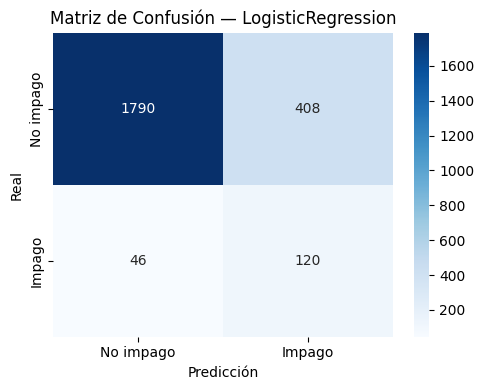

Recall en test: 0.7229


In [24]:
# Evaluación final en test
y_pred = gs.best_estimator_.predict(X_test[features_ganadoras])

print('=== EVALUACIÓN EN TEST ===')
print(classification_report(y_test, y_pred, target_names=['No impago', 'Impago']))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No impago', 'Impago'],
            yticklabels=['No impago', 'Impago'])
plt.title(f'Matriz de Confusión — {modelo_ganador_nombre}')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

recall_test = recall_score(y_test, y_pred)
print(f'Recall en test: {recall_test:.4f}')

### EXTRA — PCA como método de selección

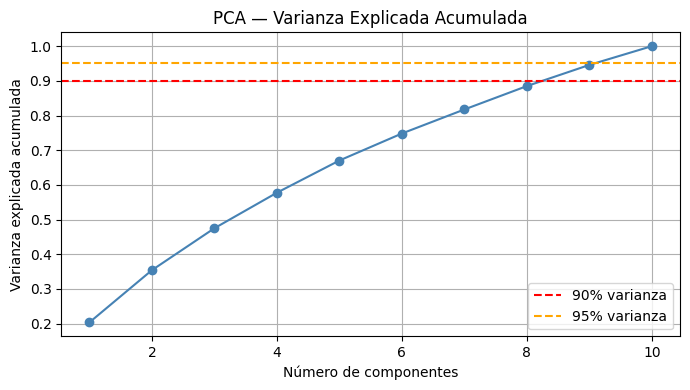

Componentes para explicar ≥90% de varianza: 9


In [25]:
# Escalar los datos completos
scaler_pca = StandardScaler()
X_train_sc = scaler_pca.fit_transform(X_train)
X_test_sc  = scaler_pca.transform(X_test)

# PCA completo para analizar varianza explicada
pca_full = PCA(random_state=42)
pca_full.fit(X_train_sc)

varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', color='steelblue')
plt.axhline(y=0.90, color='red', linestyle='--', label='90% varianza')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95% varianza')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA — Varianza Explicada Acumulada')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Número de componentes para 90% de varianza
n_comp = np.argmax(varianza_acumulada >= 0.90) + 1
print(f'Componentes para explicar ≥90% de varianza: {n_comp}')

In [26]:
# Aplicar PCA con n_comp componentes
pca = PCA(n_components=n_comp, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)

print(f'Dimensión reducida: {X_train_pca.shape[1]} componentes (original: {X_train.shape[1]} features)')

Dimensión reducida: 9 componentes (original: 10 features)


In [27]:
# Entrenamos el mismo tipo de modelo ganador sobre los componentes PCA
from sklearn.base import clone

modelo_pca = clone(modelos[modelo_ganador_nombre])

# Si el modelo ganador fue LR, usamos los mismos mejores params
# Si fue RF o GB, seteamos los mejores params encontrados
best_params = {k.replace('model__', ''): v for k, v in gs.best_params_.items()}
modelo_pca.set_params(**best_params)

modelo_pca.fit(X_train_pca, y_train)
y_pred_pca = modelo_pca.predict(X_test_pca)

print('=== EVALUACIÓN PCA EN TEST ===')
print(classification_report(y_test, y_pred_pca, target_names=['No impago', 'Impago']))

recall_pca = recall_score(y_test, y_pred_pca)
print(f'Recall en test (PCA): {recall_pca:.4f}')
print(f'Recall en test (features originales): {recall_test:.4f}')

=== EVALUACIÓN PCA EN TEST ===
              precision    recall  f1-score   support

   No impago       0.98      0.82      0.89      2198
      Impago       0.23      0.74      0.35       166

    accuracy                           0.81      2364
   macro avg       0.60      0.78      0.62      2364
weighted avg       0.92      0.81      0.85      2364

Recall en test (PCA): 0.7410
Recall en test (features originales): 0.7229


In [28]:
# Comparativa final
print('=== COMPARATIVA FINAL ===')
print(f'Modelo con features seleccionadas ({len(features_ganadoras)} features) -> Recall test: {recall_test:.4f}')
print(f'Modelo con PCA ({n_comp} componentes)                              -> Recall test: {recall_pca:.4f}')
print()
print('Conclusión:')
if recall_test >= recall_pca:
    print(f'  La selección de features ({lista_ganadora_nombre}) supera o iguala a PCA.')
    print(f'  La selección manual mantiene la interpretabilidad de las variables,')
    print(f'  ventaja importante en un contexto de crédito donde hay que explicar las decisiones.')
else:
    print(f'  PCA obtiene mejor recall ({recall_pca:.4f} vs {recall_test:.4f}).')
    print(f'  Sin embargo, los componentes principales no son directamente interpretables,')
    print(f'  lo cual es una limitación importante en scoring de crédito.')

=== COMPARATIVA FINAL ===
Modelo con features seleccionadas (6 features) -> Recall test: 0.7229
Modelo con PCA (9 componentes)                              -> Recall test: 0.7410

Conclusión:
  PCA obtiene mejor recall (0.7410 vs 0.7229).
  Sin embargo, los componentes principales no son directamente interpretables,
  lo cual es una limitación importante en scoring de crédito.
